# Project: Credit Card Fraud Data Cleaning & Analysis
**Objective**
Clean a messy financial dataset, handle missing values (artificially introduced), detect outliers, and produce insights about fraud patterns.

**Dataset**
Download the csv from following link: 
https://github.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/blob/master/creditcard.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [60]:
import seaborn as sns

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759088e-12,-8.251210e-13,-9.655224e-13,8.321417e-13,1.650335e-13,4.248462e-13,-3.054652e-13,8.777941e-14,-1.179734e-12,...,-3.405795e-13,-5.723161e-13,-9.725925e-13,1.464150e-12,-6.987098e-13,-5.617860e-13,3.332081e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df.shape

(284807, 31)

In [9]:
df["Class"].unique()

array([0, 1])

In [ ]:
# Class imbalance check
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [ ]:
# viewing in %
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

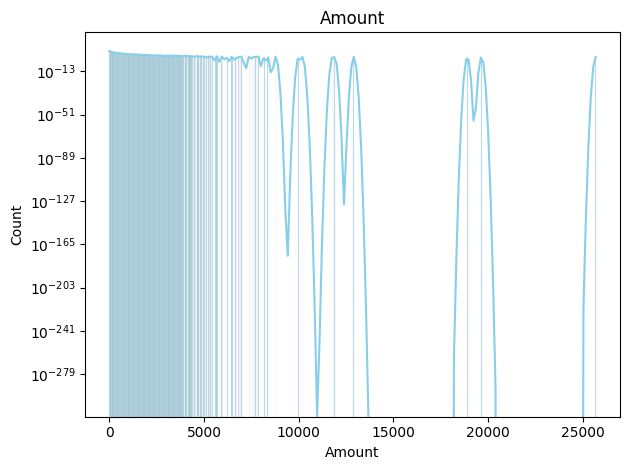

In [ ]:
# Distribution of Key Numerical Variables
sns.histplot(df["Amount"], kde=True,  color='skyblue')
plt.title("Amount")
plt.yscale('log') # added to see all the skewed data clearly
plt.tight_layout()
plt.show()

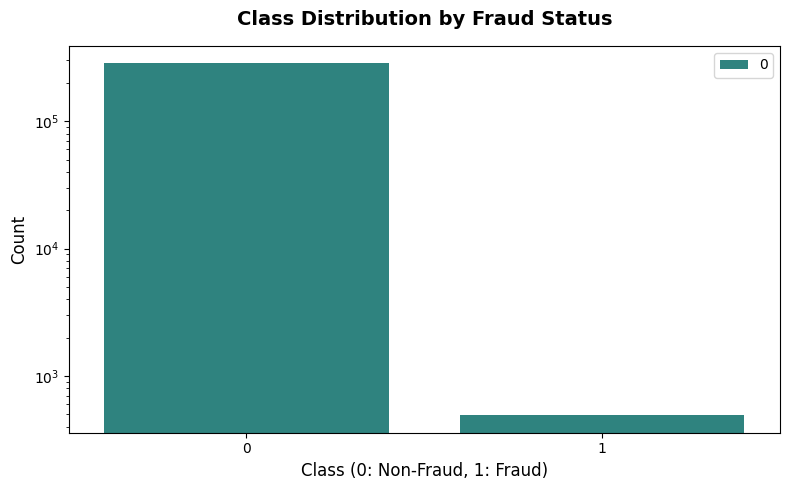

In [ ]:
# Set up the plotting environment 
plt.figure(figsize=(8, 5))

# Create the countplot
sns.countplot(x='Class', data=df, palette='viridis', hue=0)

plt.title("Class Distribution by Fraud Status", fontsize=14, pad=15, weight='bold')
plt.xlabel("Class (0: Non-Fraud, 1: Fraud)", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add to make the rare class visible!
plt.yscale('log')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1007/3178092281.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'])
/tmp/ipykernel_1007/3178092281.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'])


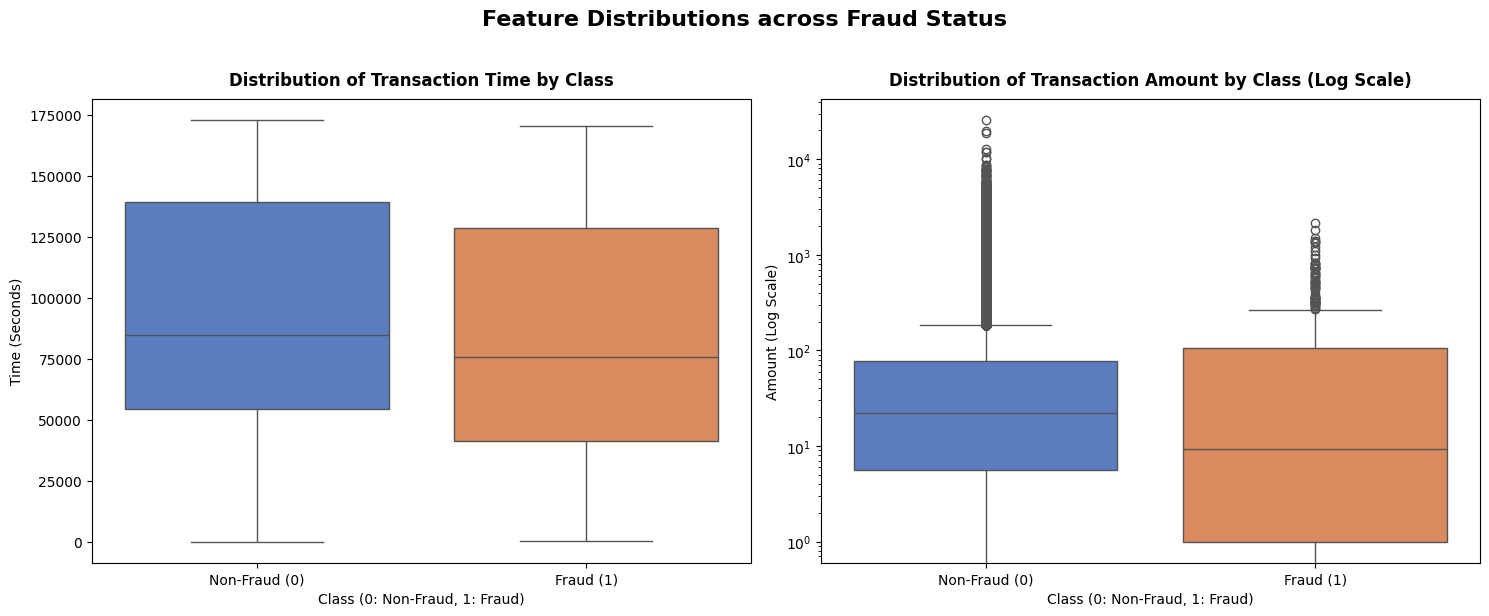

In [ ]:
# 1. Initialize a 1-row, 2-column subplot grid
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# --- Plot 1: Time vs Class ---
sns.boxplot(x='Class', y='Time', data=df, ax=axes[0], palette='muted',hue='Class', legend=False)

axes[0].set_title('Distribution of Transaction Time by Class', fontsize=12, weight='bold', pad=10)
axes[0].set_xlabel('Class (0: Non-Fraud, 1: Fraud)', fontsize=10)
axes[0].set_ylabel('Time (Seconds)', fontsize=10)
axes[0].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'])

# --- Plot 2: Amount vs Class ---
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1], palette='muted',hue='Class',legend=False)
# Because transaction amounts are heavily skewed (mostly small, few massive ones),
# we apply a log scale to the y-axis so you can actually see the distribution differences.
axes[1].set_yscale('log')

axes[1].set_title('Distribution of Transaction Amount by Class (Log Scale)', fontsize=12, weight='bold', pad=10)
axes[1].set_xlabel('Class (0: Non-Fraud, 1: Fraud)', fontsize=10)
axes[1].set_ylabel('Amount (Log Scale)', fontsize=10)
axes[1].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'])

# 2. Final Layout Polish
plt.suptitle('Feature Distributions across Fraud Status', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

<!--  Initial Inspection  -->

This dataset contains:
1. 284807 rows and 31 columns
2. No null values
3. Target is class with 0 and 1 values
4. Time is in seconds (float64, can see 1.0, 2.0, etc.)
5. Min amount 0 and max amount 25691
6. Amount likely to be right skewed (median < mean), also can see in the figure that there are very few people whos amount are very high than the rest/average (a long tail).
7. Huge class imbalance, Only 0.17% data are fraud in this class.
8. Just by looking at the 'Feature distribution across Fraud status' can see too many outliers in Amount.

Lets introduce some missing values at random.

In [33]:
# to preserve the original dataset lets use the copy
df_copy = df.copy()

In [ ]:
# Deliberately set 3% of Amount values to NaN randomly.
df_copy.loc[df_copy.sample(frac=0.03,random_state=42).index, "Amount"] = np.nan

In [45]:
df_copy["Amount"].isna().sum()

np.int64(8544)

In [39]:
# Deliberately set 2% of Time values to NaN only when Class == 1 (i.e., missingness depends on fraud status – this is MAR).
index_time = df_copy[df_copy["Class"]==1].sample(frac=0.02,random_state=42).index
df_copy.loc[index_time,"Time"] = np.nan


In [56]:
missing_count = df_copy.isna().mean() * 100
missing_count[missing_count>0]

Time      0.003511
Amount    2.999926
dtype: float64

From missing count we can see total 3% of missing in amount, and 0.003% (very tiny) missing in time as fraud cases were very few and we only selected 2% of them. 

MCAR, MAR, MNAR
> 1. The Amount column value is missing on its own, and completely at random without affecting any other variables. So, this missing is consider **MCAR** Missing Completely at Random.
> 2. The Time column value is only missing on the fraude cases. The missing values are directly related to one class only so this is **MAR** Missing at Random. Dropping it will introduce massive bias and could destroy model performance. And, we will keep it as it is.
> 
> We will look at this in detail with plots.

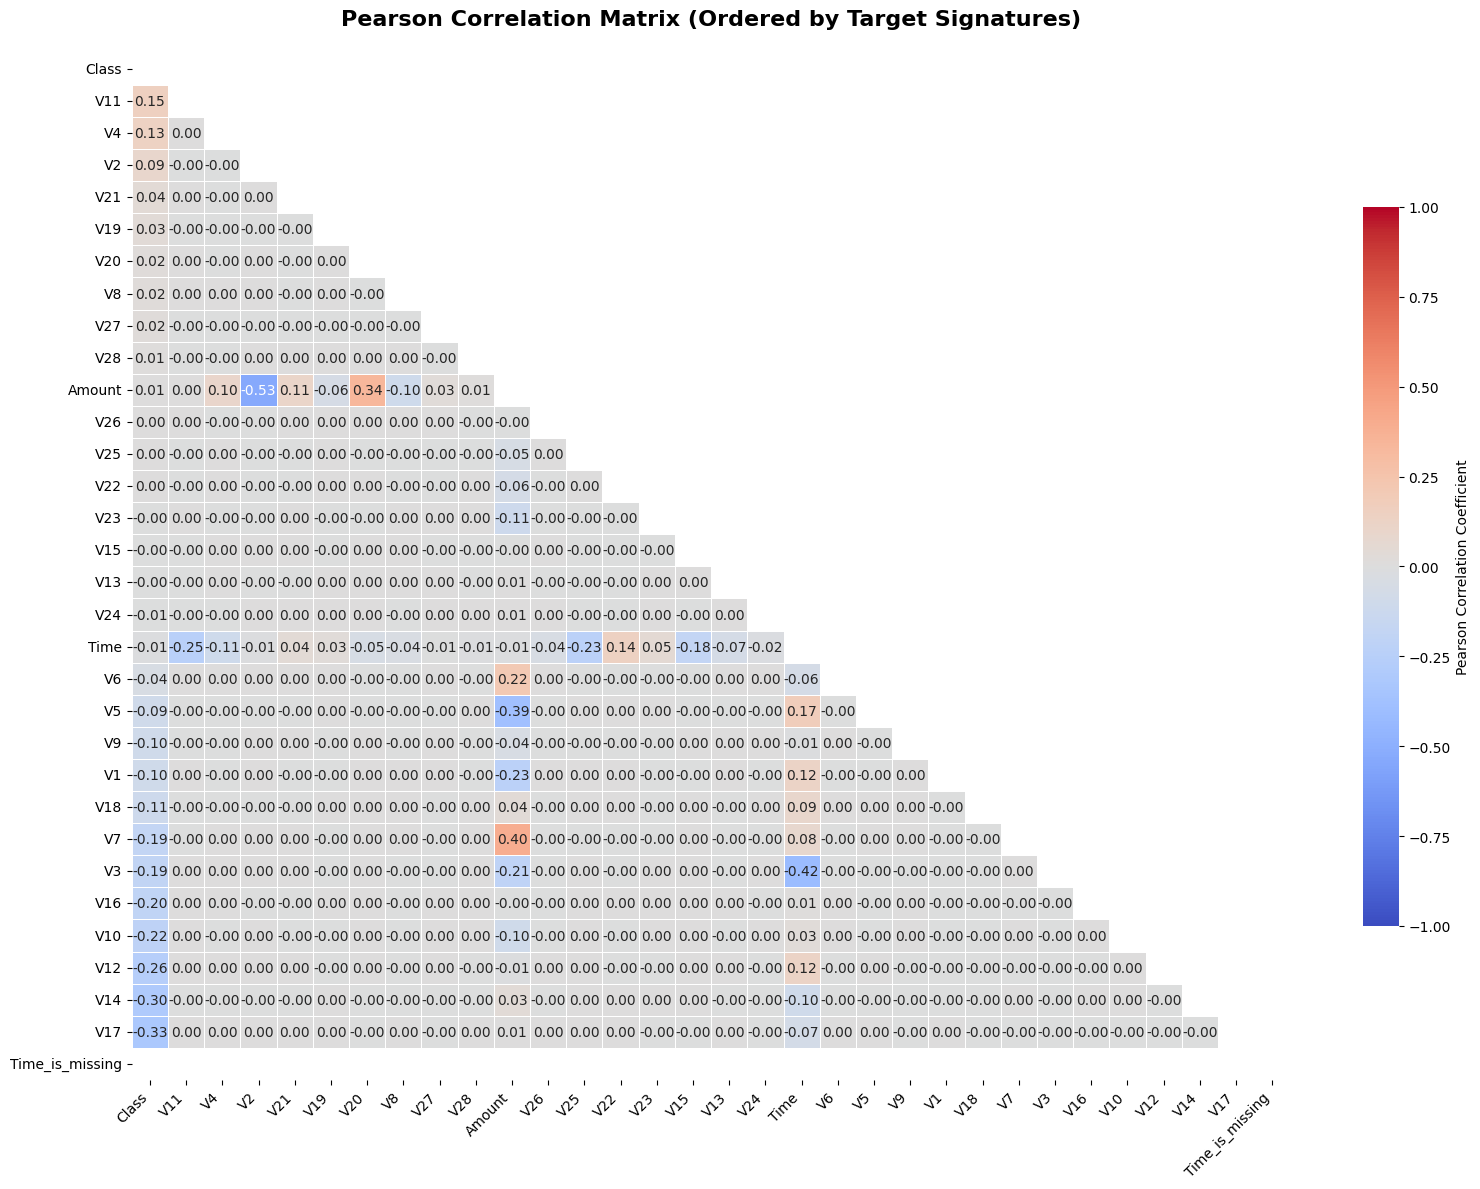

In [149]:

# 1. Isolate numerical columns safely
numerical_cols = df.select_dtypes(include=[np.number]).columns

# 2. Calculate the raw Pearson correlation matrix
correlation_matrix = df[numerical_cols].corr(method='pearson')

# 3. Sort the matrix by the target variable 'Class' 
# This groups highly correlated features together and positions 'Class' perfectly on the axis.
if 'Class' in correlation_matrix.columns:
    sorted_features = correlation_matrix['Class'].sort_values(ascending=False).index
    correlation_matrix = correlation_matrix.loc[sorted_features, sorted_features]

# 4. Create a mask for the upper triangle to eliminate redundant visual data
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 5. Dynamic sizing: Adjust figure size based on the number of features dynamically
num_features = len(numerical_cols)
fig_width = max(12, int(num_features * 0.5))
fig_height = max(10, int(num_features * 0.4))

plt.figure(figsize=(fig_width, fig_height))

# 6. Render the clean heatmap
sns.heatmap(
    correlation_matrix, 
    mask=mask,                  # Hides the upper duplicate triangle
    annot=True,                 # Shows the coefficients
    cmap='coolwarm',            # Diverging color palette (Blue = Negative, Red = Positive)
    fmt=".2f",                  # Rounded to 2 decimal places
    linewidths=.5,              # Adds a clean boundary grid line
    vmin=-1, vmax=1,            # Locks the scale boundary perfectly to Pearson limits
    cbar_kws={"shrink": .7, "label": "Pearson Correlation Coefficient"} # Cleans up the color bar
)

# 7. Polished typography and presentation
plt.title('Pearson Correlation Matrix (Ordered by Target Signatures)', fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

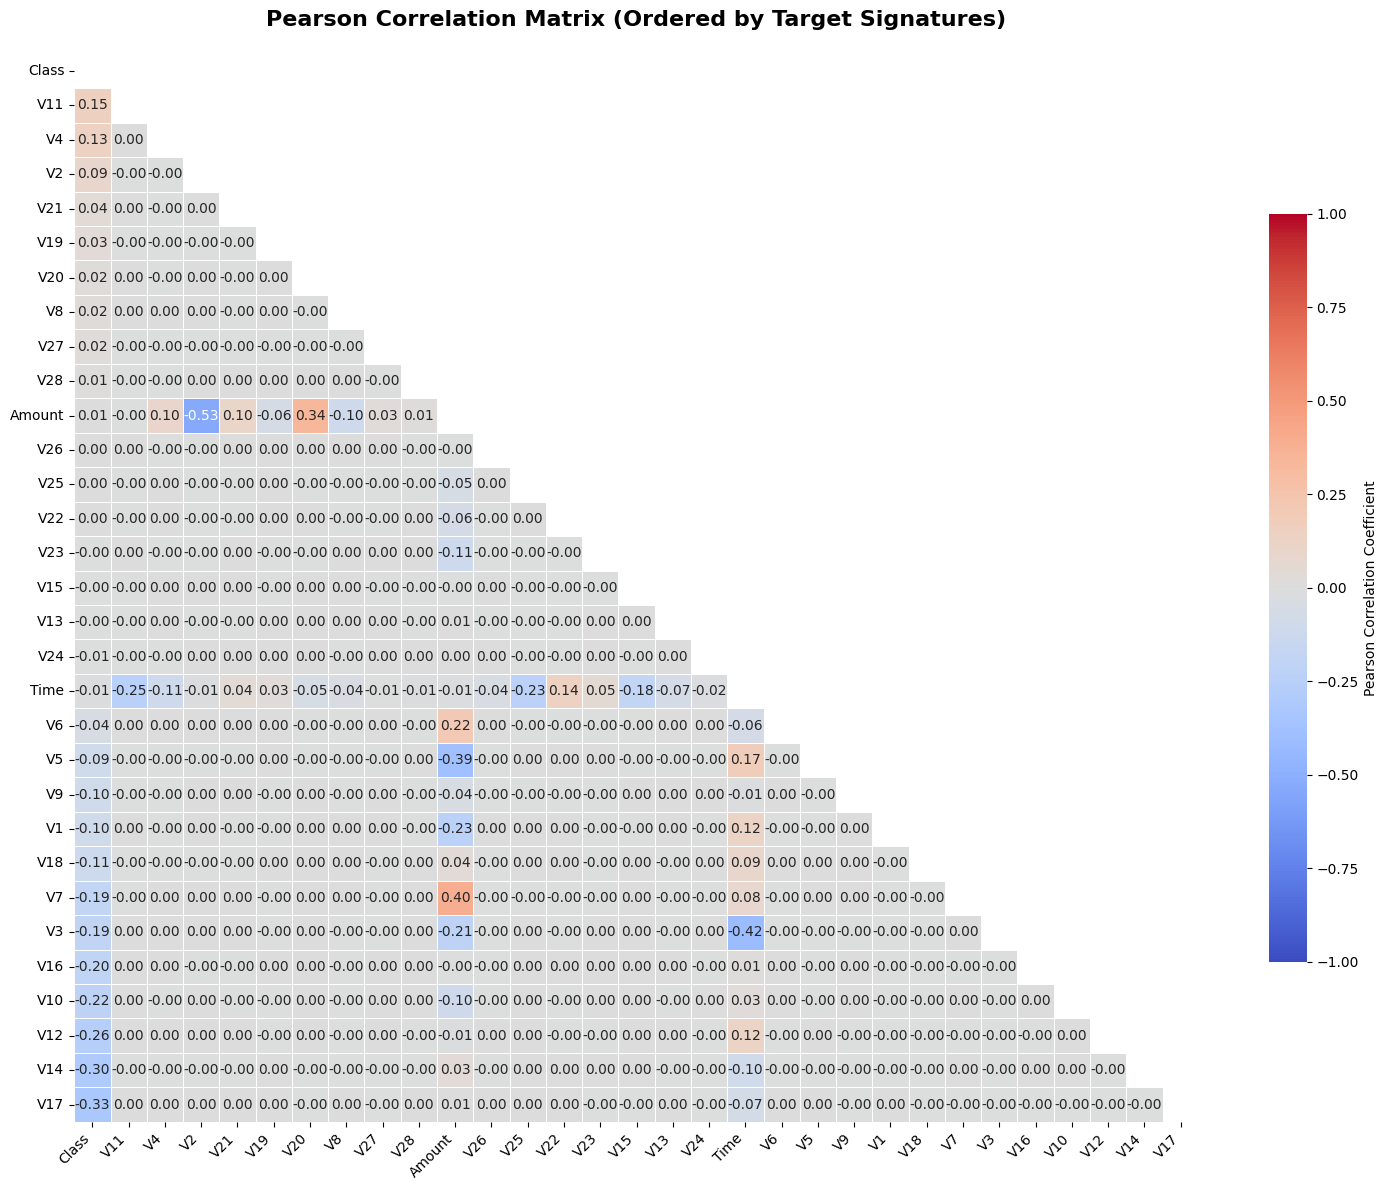

In [ ]:

# 1. Isolate numerical columns safely
numerical_cols = df_copy.select_dtypes(include=[np.number]).columns

# 2. Calculate the raw Pearson correlation matrix
correlation_matrix = df_copy[numerical_cols].corr(method='pearson')

# 3.  Sort the matrix by the target variable 'Class' 
# This groups highly correlated features together and positions 'Class' perfectly on the axis.
if 'Class' in correlation_matrix.columns:
    sorted_features = correlation_matrix['Class'].sort_values(ascending=False).index
    correlation_matrix = correlation_matrix.loc[sorted_features, sorted_features]

# 4. Create a mask for the upper triangle to eliminate redundant visual data
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 5. Dynamic sizing: Adjust figure size based on the number of features dynamically
num_features = len(numerical_cols)
fig_width = max(12, int(num_features * 0.5))
fig_height = max(10, int(num_features * 0.4))

plt.figure(figsize=(fig_width, fig_height))

# 6. Render the clean heatmap
sns.heatmap(
    correlation_matrix, 
    mask=mask,                  # Hides the upper duplicate triangle
    annot=True,                 # Shows the coefficients
    cmap='coolwarm',            # Diverging color palette (Blue = Negative, Red = Positive)
    fmt=".2f",                  # Rounded to 2 decimal places
    linewidths=.5,              # Adds a clean boundary grid line
    vmin=-1, vmax=1,            # Locks the scale boundary perfectly to Pearson limits
    cbar_kws={"shrink": .7, "label": "Pearson Correlation Coefficient"} # Cleans up the color bar
)

# 7. Polished typography and presentation
plt.title('Pearson Correlation Matrix (Ordered by Target Signatures)', fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

Since the only 0.17% data was modified on time where class = 1, the pearson coreleation is not showing any meaningful data here deu to very small number. 

We can see the amount is corelated mild positive with few v7, mild negative on v21, etc. 

No strong positive or weak corelation found here.


Even after original vs imputed matrix, there is no visual difference.

In [109]:
# Now lets look at few imputation strategies
# We will create new columns for the imputation to keep the nan as it is.
df_copy_amount1 = df_copy[["Time","Amount"]].copy()

# Median imputation (global)
amount_median = df_copy_amount1["Amount"].median()
df_copy_amount1["Amount_median"] = df_copy_amount1["Amount"].fillna(amount_median)

# Forward fill after sorting by Time
df_copy_amount1 = df_copy_amount1.sort_values(by="Time").copy()
df_copy_amount1["Amount_ffil"] = df_copy_amount1["Amount"].ffill().bfill() # This resulted into first amount nan to be nan so, we will bfil as well.


# Create a flag column Amount_missing (1 if original was missing, else 0) and keep missing values (no imputation for this flag).
df_copy_amount1["Amount_missing"] = df_copy_amount1["Amount"].isna().astype(int) # First it creates boolean value then converts to 0 and 1.
df_copy_amount1

,Time,Amount,Amount_median,Amount_ffil,Amount_missing
0,0.0,NaN,22.00,2.69,1
1,0.0,2.69,2.69,2.69,0
2,1.0,378.66,378.66,378.66,0
3,1.0,123.50,123.50,123.50,0
4,2.0,69.99,69.99,69.99,0
...,...,...,...,...,...
74794,NaN,311.91,311.91,311.91,0
143333,NaN,0.00,0.00,0.00,0
149357,NaN,38.76,38.76,38.76,0
154454,NaN,147.87,147.87,147.87,0


*“Forward fill is used here only for methodological demonstration. In practice, for transaction data without natural ordering, median imputation or model‑based imputation would be preferred.”*

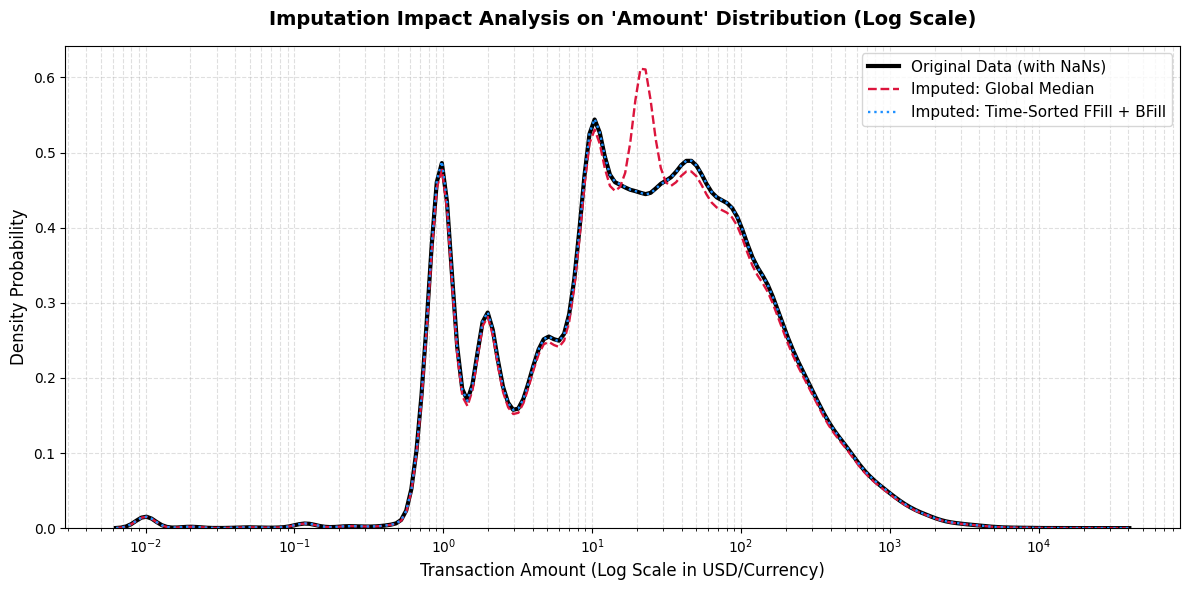

In [110]:
# Set up a clean, professional plotting canvas
plt.figure(figsize=(12, 6))

# Define the columns we want to compare
strategies = {
    "Original Data (with NaNs)": "Amount",
    "Imputed: Global Median": "Amount_median",
    "Imputed: Time-Sorted FFill + BFill": "Amount_ffil"
}

# Define a professional color palette and line styling
styles = {
    "Original Data (with NaNs)": {"color": "black", "linewidth": 3.0, "linestyle": "-"},
    "Imputed: Global Median": {"color": "crimson", "linewidth": 1.7, "linestyle": "--"},
    "Imputed: Time-Sorted FFill + BFill": {"color": "dodgerblue", "linewidth": 1.7, "linestyle": ":"}
}

# Loop through and plot each line
for label, col_name in strategies.items():
    # Senior safety check: Filter out 0 or negative values to prevent log errors
    visual_data = df_copy_amount1[df_copy_amount1[col_name] > 0][col_name]
    
    sns.kdeplot(
        visual_data,
        label=label,
        log_scale=True,  # Automatically converts the x-axis to a clean Log Scale
        ax=plt.gca(),
        **styles[label]
    )

# Polishing the typography and layout
plt.title("Imputation Impact Analysis on 'Amount' Distribution (Log Scale)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Transaction Amount (Log Scale in USD/Currency)", fontsize=12)
plt.ylabel("Density Probability", fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.4) # Subtle gridlines help read log axes
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

As the data is skewed, used log scale to see the clear view.

The imputation with ffill + bfill shows no spike or anything unusual and stays intact with original data where as with global median, in the middle we can see a huge spike (mountain view) which disorts the original dataflow. 

## Type Casting & Outliers

All the columns are in correct dtype as seen from .info().

In [ ]:
# (Code from ai)
# Calculate IQR Global 
# 1. Calculate Quantiles (ignoring NaNs automatically)
q1 = df_copy_amount1["Amount"].quantile(0.25)
q3 = df_copy_amount1["Amount"].quantile(0.75)
iqr = q3 - q1

# 2. Define the Global IQR Bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"25th Percentile (Q1): {q1:.2f}")
print(f"75th Percentile (Q3): {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Global Lower Bound: {lower_bound:.2f}")
print(f"Global Upper Bound: {upper_bound:.2f}")

25th Percentile (Q1): 5.62
75th Percentile (Q3): 77.19
IQR: 71.58
Global Lower Bound: -101.75
Global Upper Bound: 184.55


Generally amount cannot be negative, but here we can see the lower bound to be -101. 

In [ ]:
# Detect outliers in Amount using IQR (global bounds)
mask1 = (df_copy_amount1["Amount"] < lower_bound) | (df_copy_amount1["Amount"] > upper_bound)
df_copy_amount1["outlier_global"] = mask1.astype(int)
df_copy_amount1

,Time,Amount,Amount_median,Amount_ffil,Amount_missing,outlier_global
0,0.0,NaN,22.00,2.69,1,0
1,0.0,2.69,2.69,2.69,0,0
2,1.0,378.66,378.66,378.66,0,1
3,1.0,123.50,123.50,123.50,0,0
4,2.0,69.99,69.99,69.99,0,0
...,...,...,...,...,...,...
74794,NaN,311.91,311.91,311.91,0,1
143333,NaN,0.00,0.00,0.00,0,0
149357,NaN,38.76,38.76,38.76,0,0
154454,NaN,147.87,147.87,147.87,0,0


In [133]:
# Detect outliers in Amount separately for Class 0 and Class 1
# outlier_by_class
# 1. Bring the 'Class' column into the dataframe safely
df_copy_amount1["Class"] = df_copy["Class"]

# 2. Compute Q1 and Q3 dynamically per Class group
q1_per_class = df_copy_amount1.groupby("Class")["Amount"].transform("quantile", 0.25)
q3_per_class = df_copy_amount1.groupby("Class")["Amount"].transform("quantile", 0.75)
iqr_per_class = q3_per_class - q1_per_class

# 3. Define the group-specific upper and lower thresholds
lower_bounds = q1_per_class - 1.5 * iqr_per_class
upper_bounds = q3_per_class + 1.5 * iqr_per_class

# 4. Create the conditional mask comparing individual values to their group thresholds
class_outlier_mask = (df_copy_amount1["Amount"] < lower_bounds) | (df_copy_amount1["Amount"] > upper_bounds)

# 5. Convert to 1s and 0s
df_copy_amount1["outlier_by_class"] = class_outlier_mask.astype(int)
df_copy_amount1

,Time,Amount,Amount_median,Amount_ffil,Amount_missing,outlier_global,Class,outlier_by_class
0,0.0,NaN,22.00,2.69,1,0,0,0
1,0.0,2.69,2.69,2.69,0,0,0,0
2,1.0,378.66,378.66,378.66,0,1,0,1
3,1.0,123.50,123.50,123.50,0,0,0,0
4,2.0,69.99,69.99,69.99,0,0,0,0
...,...,...,...,...,...,...,...,...
74794,NaN,311.91,311.91,311.91,0,1,1,1
143333,NaN,0.00,0.00,0.00,0,0,1,0
149357,NaN,38.76,38.76,38.76,0,0,1,0
154454,NaN,147.87,147.87,147.87,0,0,1,0


In [134]:
df_copy_amount1["outlier_by_class"].sum()

np.int64(30996)

In [135]:
df_copy_amount1["outlier_global"].sum()

np.int64(30963)

Grouped/class outlier sucesfully grabbed the outliers which were missed by the global outlier. By calcualting outliers for each class we tend to remove the bias, as the class is highly imbalanced. The one class extreme outlier can change the range of IQR for another class in global outlier which fails to cover all the outliers present. 

Currenly the outlier are not being interpreted or treated, in future the outlier might be used seperately for the analysis instead of dropping or imputing them. As the extreme cases/outliers could affect model performance. The outliers are treated seperately to analyze their relations with the model comparing with non-outliars. 

 GroupBy Analysis (Business Insights)
 For each Class, compute:

Mean, median, std of Amount

90th percentile of Amount

Using groupby + agg, produce a clean summary DataFrame.

Visualisation: Create two histograms (side by side or overlaid) of Amount for Class 0 and Class 1. Use log scale on x‑axis because of extreme values.

In [ ]:
# Wrote mistake (with ai)
class_summary_table = df_copy_amount1.groupby("Class")["Amount_ffil"].agg(
    mean='mean',
    median='median',
    std='std',
    quantile_90=lambda x: x.quantile(0.9)  # Custom lambda for the 90th percentile
)

print(class_summary_table)

             mean  median         std  quantile_90
Class                                             
0       88.384074   22.00  250.847385      202.950
1      116.112480    9.25  249.721738      323.394


“Fraudulent transactions have a higher mean but a much lower median than genuine transactions. This indicates that fraud amounts are heavily right‑skewed: most frauds are small (median 9.25) but a few are extremely large (90thpercentile 323 vs 203 for genuine).”

In [148]:
# Wrote mistake (with ai)
class_summary_table2 = df_copy_amount1.groupby("Class")["Amount_median"].agg(
    mean='mean',
    median='median',
    std='std',
    quantile_90=lambda x: x.quantile(0.9)  # Custom lambda for the 90th percentile
)

print(class_summary_table2)

             mean  median         std  quantile_90
Class                                             
0       86.345058   22.00  247.069815      199.760
1      115.602073   11.19  249.749718      323.394


In Non-fraud cases, the mean dropped by 2, median stayed same and and almost changed by 3 on std and quantile 90,
and on fraud cases, mean decreased by 1, median increased by 2 and other stayed same. 

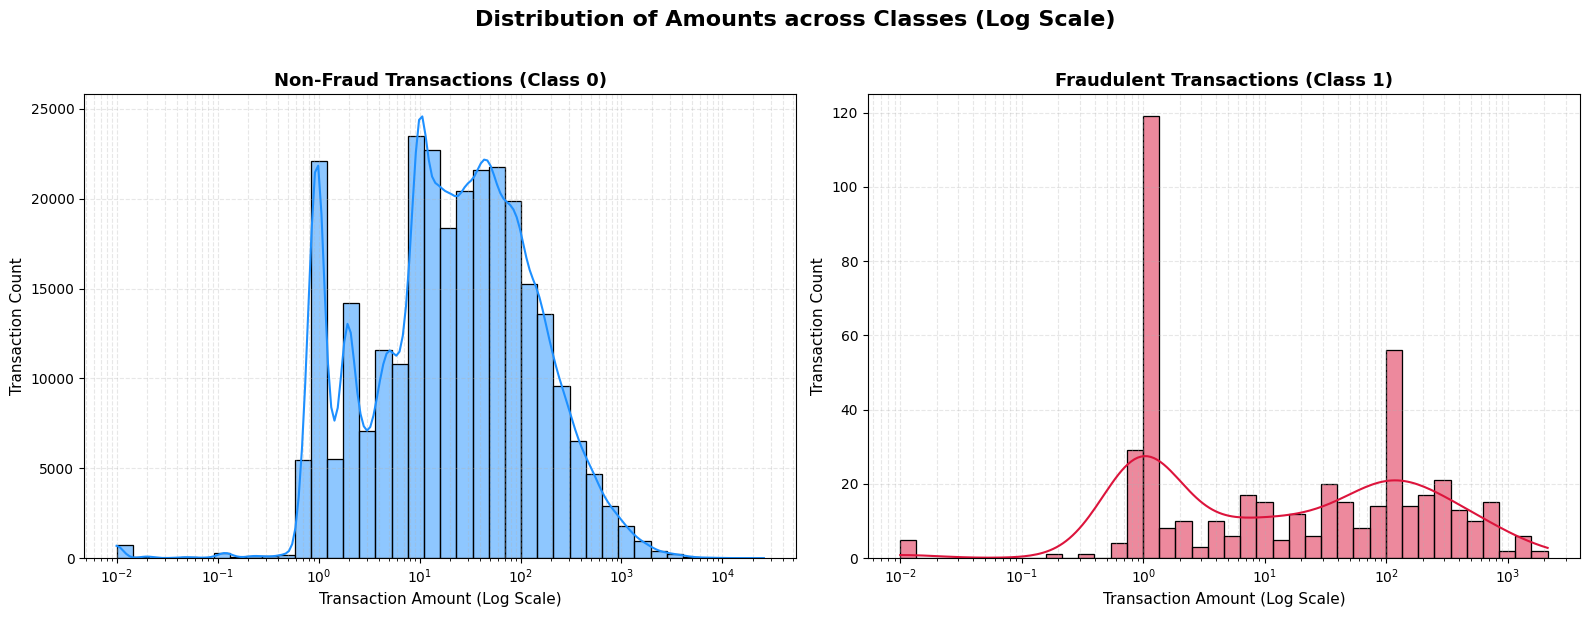

In [ ]:
# 1. Initialize a 1-row, 2-column subplot canvas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), sharey=False)

# Filter out 0 or negative amounts to prevent log scale math errors
df_visual = df_copy_amount1[df_copy_amount1["Amount_ffil"] > 0]

# --- Plot 1: Class 0 (Non-Fraud) ---
sns.histplot(
    data=df_visual[df_visual["Class"] == 0],
    x="Amount_ffil",
    log_scale=True,        # Automatically transforms x-axis and bins to log scale
    color="dodgerblue",
    kde=True,              # Adds a kernel density line for smooth contour tracking
    bins=40,
    ax=axes[0]
)
axes[0].set_title("Non-Fraud Transactions (Class 0)", fontsize=13, weight="bold")
axes[0].set_xlabel("Transaction Amount (Log Scale)", fontsize=11)
axes[0].set_ylabel("Transaction Count", fontsize=11)
axes[0].grid(True, which="both", linestyle="--", alpha=0.3)

# --- Plot 2: Class 1 (Fraud) ---
sns.histplot(
    data=df_visual[df_visual["Class"] == 1],
    x="Amount_ffil",
    log_scale=True,
    color="crimson",
    kde=True,
    bins=40,
    ax=axes[1]
)
axes[1].set_title("Fraudulent Transactions (Class 1)", fontsize=13, weight="bold")
axes[1].set_xlabel("Transaction Amount (Log Scale)", fontsize=11)
axes[1].set_ylabel("Transaction Count", fontsize=11)
axes[1].grid(True, which="both", linestyle="--", alpha=0.3)

# 2. Global Polish
plt.suptitle("Distribution of Amounts across Classes (Log Scale)", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

In the figure we can see in both few outliers which were causing the long tail, mostly data points sits in the one small range.